In [1]:
System.out.println("Hello from IJava quick demo");

Hello from IJava quick demo


In [2]:
// Inline class defined directly in a cell
class InlineGreeter {
  String name;
  InlineGreeter(String name) { this.name = name; }
  String greet() { return "Hello " + name; }
}

InlineGreeter ig = new InlineGreeter("Cell");
System.out.println(ig.greet());

Hello Cell


## List magics
Show registered line and cell magics.

In [3]:
%listMagic

registered line magics: 
	- pom, loadFromPOM
	- listMagic, list
	- read
	- listLineMagic
	- listCellMagic
	- maven, addMavenDependencies, addMavenDependency
	- printerPrefix
	- cmd
	- printWithName
	- jars
	- load
	- commonshellcmd
	- write
	- classpath
	- addMavenRepo, mavenRepo
registered cell magics: 
	- javasrcClassByName
	- write
	- plantUMLFile
	- compile
	- rdbmsSchema
	- javasrcMethodByName
	- javasrcMethodByAnnotationName
	- timeIt, timeit, time
	- shell
	- javasrcList
	- myshell
	- sqlAsTable
	- javasrcInterfaceByName
	- plantUML
	- mycompile
	- commonshell
	- pom, loadFromPOM


## Classpath & dependencies
Add Maven artifacts and jars to the runtime classpath.

In [4]:
%maven org.apache.commons:commons-text:1.10.0
%jars org.apache.commons:commons-lang3:3.12.0
import org.apache.commons.text.WordUtils;
System.out.println(WordUtils.capitalizeFully("iJava demo using maven/jars"));

Ijava Demo Using Maven/jars


## Compiler — `%%compile` (annotation-processor aware)
Use `%%compile` to compile sources with `javac` and run annotation processors (e.g., Lombok).

Note: Small classes and quick snippets can often be defined directly inside a code cell (JShell-style) without using `%%compile` — these are convenient for fast experimentation and short-lived definitions (see the previous cell).
However, `%%compile` is required when you need annotation-processing (for example Lombok), when compiling multi-file packages, or when you want to produce class files that persist on the kernel classpath for later cells.

In [5]:
%maven org.projectlombok:lombok:1.18.42

In [6]:
%%compile com.example.Greeter -v
public class Greeter {
  private final String name;
  public Greeter(String name) { this.name = name; }
  public String greet() { return "Hello " + name; }
}

11:34:39.526 [IJava-executor-0] INFO  i.g.s.i.magics.JavaCompilerMagics -- Compiling com.example.Greeter with debug=false and nowarn=false
11:34:39.533 [IJava-executor-0] INFO  i.g.s.i.magics.JavaCompilerMagics -- Source file prepared at: /var/home/bruno/.jupyter/java-workspace/src/main/java/com/example/Greeter.java
11:34:39.816 [IJava-executor-0] INFO  i.g.s.i.magics.JavaCompilerMagics -- Added to classpath: /var/home/bruno/.jupyter/java-workspace/target/classes
11:34:39.817 [IJava-executor-0] INFO  i.g.s.i.magics.JavaCompilerMagics -- Successfully compiled com.example.Greeter and added to classpath


In [7]:
import com.example.Greeter;
Greeter g = new Greeter("World");
System.out.println(g.greet());

Hello World


In [8]:
%%compile com.example.lombok.LombokExample -v
import lombok.Data;
import lombok.AllArgsConstructor;
public class LombokExample {
  @Data
  @AllArgsConstructor
  public static class Person {
    private final String name;
    private int age;
  }
  public static String test() {
    Person p = new Person("Alice", 30);
    return p.getName() + ":" + p.getAge();
  }
}

11:34:40.029 [IJava-executor-0] INFO  i.g.s.i.magics.JavaCompilerMagics -- Compiling com.example.lombok.LombokExample with debug=false and nowarn=false
11:34:40.031 [IJava-executor-0] INFO  i.g.s.i.magics.JavaCompilerMagics -- Source file prepared at: /var/home/bruno/.jupyter/java-workspace/src/main/java/com/example/lombok/LombokExample.java
11:34:40.259 [IJava-executor-0] INFO  i.g.s.i.magics.JavaCompilerMagics -- Added to classpath: /var/home/bruno/.jupyter/java-workspace/target/classes
11:34:40.259 [IJava-executor-0] INFO  i.g.s.i.magics.JavaCompilerMagics -- Successfully compiled com.example.lombok.LombokExample and added to classpath


In [9]:
import com.example.lombok.LombokExample;
System.out.println(LombokExample.test());

Alice:30


## File IO magics
Write and read a small file using `%write` and `%read`.

In [10]:
%%write /tmp/example.txt
Hello from IJava file write

Write to /tmp/example.txt success.


In [11]:
%read /tmp/example.txt

## Shell magics
Run shell commands with `%%shell` or single-line `%cmd`.

In [12]:
%%shell
uname -a
echo $SHELL
pwd

Linux pc-bruno 6.17.12-300.fc43.x86_64 #1 SMP PREEMPT_DYNAMIC Sat Dec 13 05:06:24 UTC 2025 x86_64 x86_64 x86_64 GNU/Linux
bash
/var/home/bruno/Documents/GitHub/Jupyter-Kernels/IJava/docs/notebooks


In [13]:
%cmd echo Single-line cmd via %cmd

Single-line cmd via %cmd


## Utilities
Demonstrate utility line magics: `%listLineMagic`, `%listCellMagic`, `%printerPrefix`, `%printWithName`, `%addMavenRepo`, `%pom`, `%load` (loads file into cell).

In [14]:
%listLineMagic

registered line magics: 
	- pom, loadFromPOM
	- listMagic, list
	- read
	- listLineMagic
	- listCellMagic
	- maven, addMavenDependencies, addMavenDependency
	- printerPrefix
	- cmd
	- printWithName
	- jars
	- load
	- commonshellcmd
	- write
	- classpath
	- addMavenRepo, mavenRepo


In [15]:
%listCellMagic

registered cell magics: 
	- javasrcClassByName
	- write
	- plantUMLFile
	- compile
	- rdbmsSchema
	- javasrcMethodByName
	- javasrcMethodByAnnotationName
	- timeIt, timeit, time
	- shell
	- javasrcList
	- myshell
	- sqlAsTable
	- javasrcInterfaceByName
	- plantUML
	- mycompile
	- commonshell
	- pom, loadFromPOM


In [16]:
%printerPrefix MyDemoPrefix
%printWithName -h

Change printer prefix from "" to "MyDemoPrefix"
run %printWithName to switch


In [17]:
//%addMavenRepo https://repo1.maven.org/maven2/
//%pom

## PlantUML and timing
Render PlantUML and measure execution with `%%plantUML` and `%%timeit`.

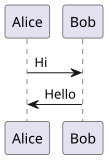

In [18]:
%%plantUML
@startuml
Alice -> Bob: Hi
Bob -> Alice: Hello
@enduml

In [19]:
%%timeit
int s = 0;
for (int i = 0; i < 10000; i++) s += i;
s

epoch 0: LongSummaryStatistics{count=5, sum=90, min=18, average=18,000000, max=18}
epoch 1: LongSummaryStatistics{count=5, sum=80, min=16, average=16,000000, max=16}
epoch 2: LongSummaryStatistics{count=5, sum=75, min=15, average=15,000000, max=15}
total: LongSummaryStatistics{count=15, sum=245, min=15, average=16,333333, max=18}


## Database schema & associations

Use the RDBMS magics to inspect database schemas and render query results as tables directly in the notebook.

Examples below call `rdbmsSchema` to print schema information and `sqlAsTable` to render SQL query results. These magics rely on a configured JDBC `EntityManagerFactory`/connection available in the kernel environment.

In [20]:
%maven com.h2database:h2:2.2.224
// Add H2 in-memory JDBC driver to the runtime classpath so the following setup can run

In [21]:
System.setProperty("jdbc.driver", "org.h2.Driver");
System.setProperty("jdbc.url", "jdbc:h2:mem:demo;DB_CLOSE_DELAY=-1;MODE=PostgreSQL");
try (java.sql.Connection c = java.sql.DriverManager.getConnection(System.getProperty("jdbc.url"))) {
    try (java.sql.Statement st = c.createStatement()) {
        st.execute("CREATE SCHEMA IF NOT EXISTS EX_PRODUCT_ORDER");
        st.execute("CREATE TABLE IF NOT EXISTS EX_PRODUCT_ORDER.PRODUCT (id BIGINT GENERATED BY DEFAULT AS IDENTITY PRIMARY KEY, name VARCHAR(255), price DOUBLE)");
        st.execute("CREATE TABLE IF NOT EXISTS EX_PRODUCT_ORDER.CUSTOMER (id BIGINT GENERATED BY DEFAULT AS IDENTITY PRIMARY KEY, name VARCHAR(255))");
        st.execute("CREATE TABLE IF NOT EXISTS EX_PRODUCT_ORDER.ORDERS (id BIGINT GENERATED BY DEFAULT AS IDENTITY PRIMARY KEY, customer_id BIGINT, order_date TIMESTAMP, FOREIGN KEY (customer_id) REFERENCES EX_PRODUCT_ORDER.CUSTOMER(id))");
        st.execute("CREATE TABLE IF NOT EXISTS EX_PRODUCT_ORDER.ORDER_LINE (id BIGINT GENERATED BY DEFAULT AS IDENTITY PRIMARY KEY, order_id BIGINT, product_id BIGINT, quantity INT, FOREIGN KEY (order_id) REFERENCES EX_PRODUCT_ORDER.ORDERS(id), FOREIGN KEY (product_id) REFERENCES EX_PRODUCT_ORDER.PRODUCT(id))");
        st.execute("INSERT INTO EX_PRODUCT_ORDER.PRODUCT(name, price) VALUES ('Pen', 1.0)");
        st.execute("INSERT INTO EX_PRODUCT_ORDER.PRODUCT(name, price) VALUES ('Paper', 5.0)");
        st.execute("INSERT INTO EX_PRODUCT_ORDER.PRODUCT(name, price) VALUES ('Car', 20000)");
        st.execute("INSERT INTO EX_PRODUCT_ORDER.CUSTOMER(name) VALUES ('Alice')");
        st.execute("INSERT INTO EX_PRODUCT_ORDER.CUSTOMER(name) VALUES ('Bob')");
        st.execute("INSERT INTO EX_PRODUCT_ORDER.ORDERS(customer_id, order_date) VALUES (1, CURRENT_TIMESTAMP())");
        st.execute("INSERT INTO EX_PRODUCT_ORDER.ORDERS(customer_id, order_date) VALUES (2, CURRENT_TIMESTAMP())");
        st.execute("INSERT INTO EX_PRODUCT_ORDER.ORDER_LINE(order_id, product_id, quantity) VALUES (1, 1, 2)");
        st.execute("INSERT INTO EX_PRODUCT_ORDER.ORDER_LINE(order_id, product_id, quantity) VALUES (1, 2, 3)");
        st.execute("INSERT INTO EX_PRODUCT_ORDER.ORDER_LINE(order_id, product_id, quantity) VALUES (2, 3, 1)");
    }
}
System.out.println("H2 in-memory demo DB initialized (jdbc.url=" + System.getProperty("jdbc.url") + ")");

H2 in-memory demo DB initialized (jdbc.url=jdbc:h2:mem:demo;DB_CLOSE_DELAY=-1;MODE=PostgreSQL)


### RDBMS Schema Diagram
Use the `%%rdbmsSchema` cell magic to render the current JDBC schema as a PlantUML diagram. The kernel uses `jdbc.url` (set earlier) to connect to the demo H2 database.

```plantuml
@startuml
left to right direction
skinparam roundcorner 5
skinparam shadowing true
skinparam entity {
    BackgroundColor #EEEEEE
    ArrowColor #2688d4
    BorderColor #2688d4
}
!define primary_key(x) <b><color:#b8861b>PK</color> x</b>
!define foreign_key(x) <color:#aaaaaa>FK</color> x
!define column(x) <color:#efefef>*</color> x
!define table(x) entity x << (T, white) >>

table(CUSTOMER) {
	primary_key(ID) : BIGINT(64)
--
	column(NAME) : CHARACTER VARYING(255)
}
table(ORDERS) {
	primary_key(ID) : BIGINT(64)
--
	foreign_key(CUSTOMER_ID) : BIGINT(64)
	column(ORDER_DATE) : TIMESTAMP(26)
}
table(ORDER_LINE) {
	primary_key(ID) : BIGINT(64)
--
	foreign_key(ORDER_ID) : BIGINT(64)
	foreign_key(PRODUCT_ID) : BIGINT(64)
	column(QUANTITY) : INTEGER(32)
}
table(PRODUCT) {
	primary_key(ID) : BIGINT(64)
--
	column(NAME) : CHARACTER VARYING(255)
	column(PRICE) : DOUBLE PRECISION(53)
}
ORDERS "0..*" --> "1" CUSTOMER : CUSTOMER_ID -> ID
ORDER_LINE "0..*" --> "1" ORDERS : ORDER_ID -> ID
ORDER_LINE "0..*" --> "1" PRODUCT : PRODUCT_ID -> ID
@enduml
```

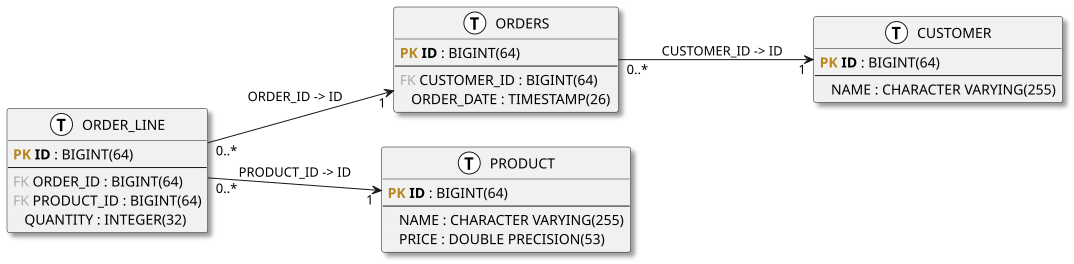

In [22]:
%%rdbmsSchema EX_PRODUCT_ORDER showSource
// leave body empty to include all tables in the schema

### SQL Results as HTML Table
Use `%%sqlAsTable` to run a query and render results as an HTML table in the notebook.

In [23]:
%%sqlAsTable
SELECT id, name, price FROM EX_PRODUCT_ORDER.PRODUCT ORDER BY id LIMIT 10 OFFSET 0;

ID,NAME,PRICE
1,Pen,1.0
2,Paper,5.0
3,Car,20000.0


### PlantUML from File
Create a PlantUML file and render it with `%%plantUMLFile`.

In [24]:
%%write /tmp/sample_schema.puml
@startuml
entity PRODUCT
entity CUSTOMER
PRODUCT ||--o{ ORDER_LINE
@enduml

Write to /tmp/sample_schema.puml success.


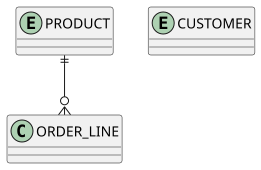

In [25]:
%%plantUMLFile
/tmp/sample_schema.puml

## Sample Java files
The folder docs/notebooks/sample_java contains small example Java sources.
Use `%load` to load a file into a cell, then `%%compile` to compile it. Example workflow:
- Cell 1: `String file = %load sample_java/com/example/Greeter.java;` (assign loaded file contents to a variable)
- Cell 2: `%%compile com.example.Greeter -v` (or run the loaded cell content with `%%compile`)
- Then import and use `com.example.Greeter` in a cell.

In [26]:
String file = %load sample_java/com/example/Greeter.java;
System.out.println(file);

11:34:42.553 [IJava-executor-0] WARN  i.g.s.ijava.magics.MagicsTool -- %load: file not found: sample_java/com/example/Greeter.java; (tried 'sample_java/com/example/Greeter.java;')
null


In [27]:
%%compile com.example.Greeter -v
public class Greeter {
  private final String name;
  public Greeter(String name) { this.name = name; }
  public String greet() { return "Hello " + name; }
}

11:34:42.653 [IJava-executor-0] INFO  i.g.s.i.magics.JavaCompilerMagics -- Compiling com.example.Greeter with debug=false and nowarn=false
11:34:42.654 [IJava-executor-0] INFO  i.g.s.i.magics.JavaCompilerMagics -- Source file prepared at: /var/home/bruno/.jupyter/java-workspace/src/main/java/com/example/Greeter.java
11:34:42.809 [IJava-executor-0] INFO  i.g.s.i.magics.JavaCompilerMagics -- Added to classpath: /var/home/bruno/.jupyter/java-workspace/target/classes
11:34:42.810 [IJava-executor-0] INFO  i.g.s.i.magics.JavaCompilerMagics -- Successfully compiled com.example.Greeter and added to classpath


In [28]:
import com.example.Greeter;
Greeter g = new Greeter("Notebook");
System.out.println(g.greet());

Hello Notebook


## Java source extractors
Quick demos for `%%javasrcList` and `%%javasrcMethodByName`. Use these to inspect local Java files and pick indices for extraction.

In [29]:
%%javasrcList
sample_java/com/example/OrderExample.java

Summary of sample_java/com/example/OrderExample.java

ClassOrInterfaceDeclaration: OrderExample
  - String summary(Product)



- `%%javasrcList file.java` prints a summary (classes, methods, signatures).
- `%%javasrcMethodByName ClassName methodRegex=^sum` finds methods by regex. Use `--raw` to get plain text output.

In [33]:
%%javasrcMethodByName --help
//need to have some text here to avoid empty cell. TODO: fix it

**Usage:** `%%javasrcMethodByName [options] <FullyQualifiedClassName|ClassName> [methodName|index]`

**Options:**
- `--src <dir>`: source root to resolve FQCN (e.g., `--src=sample_java`)
- `methodRegex=<regex>`: select methods whose name matches regex
- `selectIndex=<n>` or positional index: pick one when multiple matches
- `--raw` / `--fenced`: output format

**Examples:**
- `%%javasrcMethodByName methodRegex=summary --src=sample_java com.example.OrderExample`
- `%%javasrcMethodByName com.example.OrderExample myMethod`
- `%%javasrcMethodByName selectIndex=1 com.example.OrderExample myMethod`


In [ ]:
%%javasrcMethodByName methodRegex=summary --src=sample_java com.example.OrderExample
sample_java/com/example/OrderExample.java

Error: failed to read file `//need to have some text here to avoid empty cell. TODO: fix it`: /need to have some text here to avoid empty cell. TODO: fix it